In [1]:
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt -O KDDTrain+.txt
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt -O KDDTest+.txt

In [2]:
import pandas as pd

columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

train = pd.read_csv('KDDTrain+.txt', names=columns)
test = pd.read_csv('KDDTest+.txt', names=columns)

print(train.shape)
print(train['label'].value_counts())

(125973, 43)
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [3]:
# Map labels to attack families
attack_map = {
    'normal': 'Normal',
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS',
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'warezclient': 'R2L', 'warezmaster': 'R2L', 'guess_passwd': 'R2L',
    'imap': 'R2L', 'ftp_write': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R'
}

train['attack_family'] = train['label'].map(attack_map)
test['attack_family'] = test['label'].map(attack_map)

print(train['attack_family'].value_counts())

attack_family
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [4]:
# Drop columns we don't need
train = train.drop(columns=['label', 'difficulty'])
test = test.drop(columns=['label', 'difficulty'])

# Identify categorical columns
cat_cols = ['protocol_type', 'service', 'flag']

# Encode categoricals
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([train[col], test[col]])  # fit on both to avoid unseen labels
    le.fit(combined)
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])

print("Encoding done")
print(train.shape)

Encoding done
(125973, 42)


In [5]:
from sklearn.preprocessing import StandardScaler

X_train = train.drop(columns=['attack_family'])
y_train = train['attack_family']

X_test = test.drop(columns=['attack_family'])
y_test = test['attack_family']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # transform only, never fit on test

print("Scaling done")
print(X_train.shape)

Scaling done
(125973, 41)


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))

TypeError: '<' not supported between instances of 'float' and 'str'

In [7]:
print(test['attack_family'].isna().sum())
print(test['attack_family'].unique())

3750
['DoS' 'Normal' nan 'R2L' 'Probe' 'U2R']


In [8]:
# Drop rows where attack_family is NaN
test_clean = test.dropna(subset=['attack_family'])

X_test = test_clean.drop(columns=['attack_family'])
y_test = test_clean['attack_family']

# Re-scale
X_test = scaler.transform(X_test)

print(X_test.shape, y_test.value_counts())

(18794, 41) attack_family
Normal    9711
DoS       5741
R2L       2199
Probe     1106
U2R         37
Name: count, dtype: int64


In [9]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         DoS       0.99      1.00      0.99      5741
      Normal       0.82      0.97      0.89      9711
       Probe       0.85      1.00      0.92      1106
         R2L       0.99      0.06      0.11      2199
         U2R       0.50      0.03      0.05        37

    accuracy                           0.87     18794
   macro avg       0.83      0.61      0.59     18794
weighted avg       0.89      0.87      0.83     18794



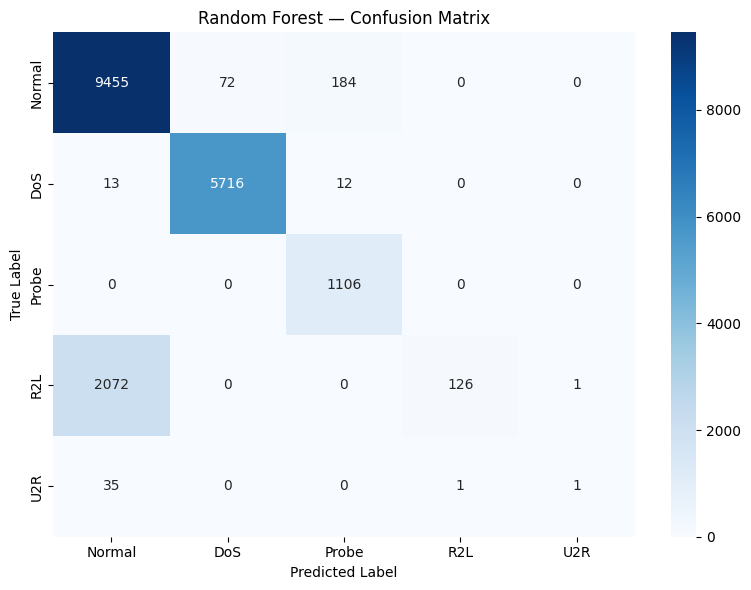

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [11]:
import joblib

joblib.dump(rf, 'ids_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved.")

Model and scaler saved.


In [12]:
from google.colab import files
files.download('ids_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

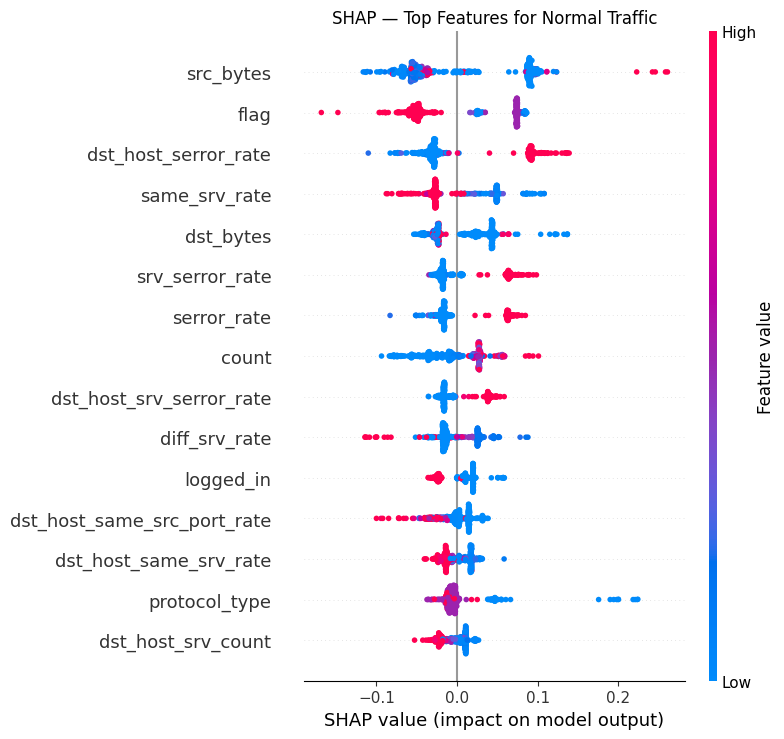

In [13]:
!pip install -q shap
import shap

# Use a small sample — SHAP on full dataset is slow
import pandas as pd
X_train_df = pd.DataFrame(X_train, columns=[
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate'
])

sample = X_train_df.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(sample)

# Summary plot — top 15 features
shap.summary_plot(shap_values[:,:,0], sample, max_display=15, show=False)
plt.title("SHAP — Top Features for Normal Traffic")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()

In [14]:
from google.colab import files
files.download('shap_summary.png')
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>